# Mineria de datos
## Regresiones

### Introducción:
*En el presente trabajo se aborda un problema de minería de datos y modelización predictiva aplicado al análisis electoral en España, utilizando información a nivel municipal. El conjunto de datos empleado contiene variables de carácter demográfico, socioeconómico y electoral, junto con distintos indicadores que resumen los resultados obtenidos en las últimas elecciones.*

*El objetivo general de la práctica es analizar y modelizar el comportamiento electoral de los municipios españoles, identificando relaciones entre las variables explicativas disponibles y determinados resultados electorales. Para ello, se plantea la construcción de dos modelos de regresión distintos, cada uno adaptado a la naturaleza de la variable objetivo considerada.*

*De entre las variables objetivo disponibles en el conjunto de datos, se selecciona:*

- *Una variable objetivo continua, que permitirá estudiar cómo influyen las características de los municipios en la magnitud de un determinado resultado electoral mediante un modelo de regresión lineal.*

- *Una variable objetivo binaria, que permitirá analizar la probabilidad de que se produzca un determinado fenómeno electoral mediante un modelo de regresión logística.*

#### *a) Depuración de datos*
- *Importación de las librerias necesarias y funciones.*

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

In [2]:
# Import custom functions
from FuncionesMineria import (graficoVcramer, mosaico_targetbinaria, boxplot_targetbinaria, 
                           hist_targetbinaria, Transf_Auto, lm, Rsq, validacion_cruzada_lm,
                           modelEffectSizes, crear_data_modelo, Vcramer, hist_target_categorica,
                            ImputacionCuant, ImputacionCuali, patron_perdidos, mejorTransfCorr,
                            mejorTransfVcramer, Transf_Auto, lm_backward, lm_forward, lm_stepwise, glm, summary_glm,
                            pseudoR2, impVariablesLog, curva_roc, glm_stepwise, glm_forward, sensEspCorte)

- *Para importar los datos se utiliza el siguiente código.*

In [3]:
# Import data
df_mineriaR = pd.read_excel('DatosEleccionesEspaña.xlsx')
df_mineriaR.head(10).T

,0,1,2,3,4,5,6,7,8,9
Name,Abadía,Abertura,Acebo,Acehúche,Aceituna,Ahigal,Alagón del Río,Albalá,Alcántara,Alcollarín
CodigoProvincia,10,10,10,10,10,10,10,10,10,10
CCAA,Extremadura,Extremadura,Extremadura,Extremadura,Extremadura,Extremadura,Extremadura,Extremadura,Extremadura,Extremadura
TotalCensus,282,364,569,704,540,1263,826,629,1320,266
AbstentionPtge,20.213,25.275,27.241,30.114,30.185,22.565,30.024,27.027,22.803,24.436
AbstencionAlta,0,0,0,1,1,0,1,0,0,0
Izda_Pct,60.444,54.779,44.203,50.813,44.562,53.068,59.343,37.037,46.81,37.811
Dcha_Pct,35.555,44.118,53.14,45.325,49.867,45.501,37.89,60.567,50.736,58.209
Otros_Pct,1.778,0.368,0.966,0.0,0.796,0.409,0.692,0.218,0.785,0.498
Izquierda,1,1,0,1,0,1,1,0,0,0


- *Para observar la composición de los datos alojados en el dataframe "df_mineriaR", se utiliza el método .indfo(). A partir del mismo, se observa que el mismo esta compuesto por 25 variables con nombres y tipos diferentes. Al ejecutar el código se observa que las variables, CodigoProvincia, CCAA, Izquierda, Derecha, AbstencionAlta, ActividadPpal, Densidad, no han sido asignadas correctamente, tal y como se muestra a continuación.*

In [4]:
# Explore data
df_mineriaR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8117 entries, 0 to 8116
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Name                          8117 non-null   object 
 1   CodigoProvincia               8117 non-null   int64  
 2   CCAA                          8117 non-null   object 
 3   TotalCensus                   8117 non-null   int64  
 4   AbstentionPtge                8117 non-null   float64
 5   AbstencionAlta                8117 non-null   int64  
 6   Izda_Pct                      8117 non-null   float64
 7   Dcha_Pct                      8117 non-null   float64
 8   Otros_Pct                     8117 non-null   float64
 9   Izquierda                     8117 non-null   int64  
 10  Derecha                       8117 non-null   int64  
 11  WomanPopulationPtge           8117 non-null   float64
 12  ForeignersPtge                8117 non-null   float64
 13  Sam

- *Estas variables en algunos casos son categóricas y en otras buleanas, por lo que se cambia su asignación con el siguiente código:* 

In [5]:
# change variables types
nuericaAcategorica = ['CodigoProvincia']
objetoAcategorica = ['CCAA', 'ActividadPpal', 'Densidad']
objetoAbuleano = ['Izquierda', 'Derecha', 'AbstencionAlta']

for col in nuericaAcategorica:
    df_mineriaR[col] = df_mineriaR[col].astype('category')
for col in objetoAcategorica:
    df_mineriaR[col] = df_mineriaR[col].astype('category')
for col in objetoAbuleano:
    df_mineriaR[col] = df_mineriaR[col].astype('bool')

- *A continuación, se muestra un análisis descriptivo de las variables explicativas, donde se destaca observar que:*
    - *TotalCensus: presenta una distribución altamente asimétrica a la derecha, con un coeficiente de asimetría muy elevado y una curtosis extremadamente alta. Esto indica la presencia de municipios con tamaños poblacionales muy superiores al resto, lo que es coherente con la estructura territorial española, donde conviven pequeños municipios rurales con grandes ciudades. No obstante, el amplio rango observado sugiere la necesidad de analizar esta variable en profundidad en la fase de detección de valores atípicos.*
    - *Otros_Pct: presenta una diferencia muy marcada entre la media y la mediana, junto con valores elevados de asimetría y curtosis, lo que indica que aunque en la mayoría de los municipios el porcentaje de voto a otros partidos es reducido, existen algunos casos con valores extremadamente altos que influyen de forma notable.*
    - *ForeignersPtge y SameComAutonDiffProvPtge: presenta asimetría posotiva y curtosis elevada, indicando que hay presencia de municipios con mas extranjeros que otros propia de una distribución con mas dispersión. Adicnalmente para el caso de ForeignersPtge su valor mínimo presenta negativos, lo que no puede ser conceptualmente*
    - *SameComAutonPtge: presenta asimetría negativa y curtosis positiva, aunque muy leve en ambos casos, se observan valores máximos que no corresponde a los valores normales que puede tomar esta variables, no pudiendo así superar el 100% de la muestra total.*
    - *Superfice: Muestra una mediana reducida y una asimetría positiva muy elevada, junto con una curtosis extremadamente alta. Este comportamiento refleja una fuerte heterogeneidad territorial y sugiere la presencia de valores atípicos.*
    - *Explotaciones: Presenta asimetría y curtoris extrema, con un valor máximo muy elejado de los valores típicos, se presume errores o datos perdidos.*

In [6]:
# Descriptive statistics
numericas_vars = df_mineriaR.select_dtypes(include=['int64', 'float64']).columns.tolist()
descriptivos_num = df_mineriaR[numericas_vars].describe().T
for num in numericas_vars:
    descriptivos_num.loc[num, "Asimetria"] = df_mineriaR[num].skew()
    descriptivos_num.loc[num, "Kurtosis"] = df_mineriaR[num].kurtosis()
    descriptivos_num.loc[num, "Rango"] = np.ptp(df_mineriaR[num].dropna().values)

descriptivos_num

,count,mean,std,min,25%,50%,75%,max,Asimetria,Kurtosis,Rango
TotalCensus,8117.0,4247.863989,34423.439346,5.0000,140.0000,447.000,1843.0000,2363829.000,46.544648,2893.452945,2.363824e+06
AbstentionPtge,8117.0,26.501647,7.533438,0.0000,21.6780,26.424,31.4710,57.576,-0.053736,0.493671,5.757600e+01
Izda_Pct,8117.0,34.403957,16.484308,0.0000,21.8910,35.165,46.0320,94.117,0.059882,-0.493538,9.411700e+01
Dcha_Pct,8117.0,48.912166,19.946471,0.0000,38.6900,51.579,62.1870,100.000,-0.467616,-0.175615,1.000000e+02
Otros_Pct,8117.0,14.669311,25.095942,0.0000,0.7590,1.883,16.5680,100.000,1.801338,1.851374,1.000000e+02
WomanPopulationPtge,8117.0,47.302297,4.362347,11.7650,45.7250,48.485,50.0000,72.683,-1.671102,5.800629,6.091800e+01
ForeignersPtge,8117.0,5.618322,7.348700,-8.9600,1.0600,3.590,8.1800,71.470,2.498262,11.356789,8.043000e+01
SameComAutonPtge,8117.0,81.633460,12.287323,0.0000,75.8060,84.493,90.4620,127.156,-1.522758,3.479538,1.271560e+02
SameComAutonDiffProvPtge,8117.0,4.337637,6.394942,0.0000,0.6760,2.190,5.2770,67.308,3.286828,14.560136,6.730800e+01
UnemployLess25_Ptge,8117.0,7.320241,9.408801,0.0000,0.0000,5.882,10.4670,100.000,4.150962,31.664819,1.000000e+02


- *En correspondencia también se analizan los descriptivos de las variales categóricas, sobre todo en sus frecuencias y unicidad:*
    - *Name: esta variable es meramente identificativa y no contiene información predictiva, ademas de presentar altisima cantidad de categorías.*
    - *CodigoProvincia: presenta muchas categorias (50) que probablemente tengan poco representatividad, la cual adicionalmente puede ser en gran parte recogida por CCAA.*
    - *CCAA: 17 categorías, distribución desigual pero con frecuencias elevadas en todas las categorías.*
    - *AbstencionAlta, Izquierda, Derehca: variables dicotomicas potenciales de ser elegidas como objetivo, se excluyen en función de la que se opte.*
    - *ActividadPpal: Fuerte desequilibrio entre categorías, potencial reagrupamiento de categorías.*
    - *Densidad: Fuerte desequilibrio entre categorías, potencial reagrupamiento de categorías.*

In [7]:
# Descriptive statistics for categorical variables
categoricas_vars = df_mineriaR.select_dtypes(include=['object', 'category', 'bool'])
categoricas_vars.describe().T

,count,unique,top,freq
Name,8117,8100,Torrent,2
CodigoProvincia,8117,50,9,371
CCAA,8117,17,CastillaLeón,2248
AbstencionAlta,8117,2,False,5591
Izquierda,8117,2,False,6308
Derecha,8117,2,True,5041
ActividadPpal,8117,5,Otro,4932
Densidad,8117,4,MuyBaja,6416


- *Al estudio anterior de las variables categoricas, se suma el estudio de frecuencias para cada valor que toman las varibales*
    - *Del mismo se evidencia que la variable "Densidad" presenta errores, siendo uno de sus valores un signo de interrogación (?)*
    - *El resto de las variables no presentan errores.*

In [8]:
# Frequency tables for categorical variables
frecuencias_categoricas_vars = {
    col: df_mineriaR[col].value_counts(dropna=False).sort_index()
    for col in categoricas_vars.columns
}
frecuencias_categoricas_vars["Densidad"] # replace "Densidad" with any categorical variable name to see its frequency table

Densidad
?            92
Alta        556
Baja       1053
MuyBaja    6416
Name: count, dtype: int64

- *A partir de este momento podemos revisar la cantidad de valores nulos dentro de nuestro dataframe con veracidad a partir del siguiente código, cuyo resultado indica poca presencia de valores perdidos:*

In [9]:
# Check for missing values
df_mineriaR.isna().sum()

Name                            0
CodigoProvincia                 0
CCAA                            0
TotalCensus                     0
AbstentionPtge                  0
AbstencionAlta                  0
Izda_Pct                        0
Dcha_Pct                        0
Otros_Pct                       0
Izquierda                       0
Derecha                         0
WomanPopulationPtge             0
ForeignersPtge                  0
SameComAutonPtge                0
SameComAutonDiffProvPtge        0
UnemployLess25_Ptge             0
AgricultureUnemploymentPtge     0
IndustryUnemploymentPtge        0
ConstructionUnemploymentPtge    0
ServicesUnemploymentPtge        0
ActividadPpal                   0
SUPERFICIE                      8
Densidad                        0
PobChange_pct                   7
Explotaciones                   0
dtype: int64

- *Se presume que alguanas variables categóricas pueden ser explicadas por otras, sera el caso para CodigoProvincia con CCAA? Para ello aplicamos V de Cramer y observamos su resultado.

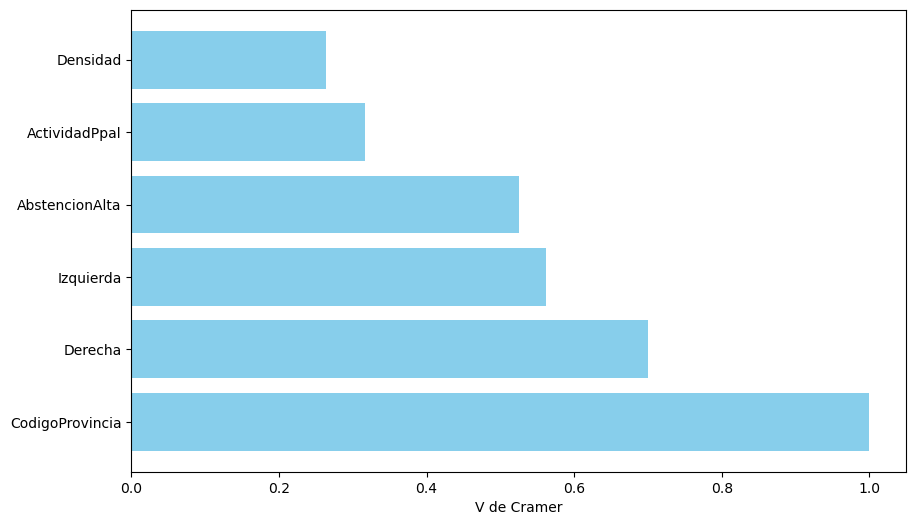

In [10]:
# Cramer's V analysis, dependence between categorical variables wwith CCAA as target
matriz = df_mineriaR[[
    "CodigoProvincia",
    "Densidad",
    "Derecha",
    "Izquierda",
    "AbstencionAlta",
    "ActividadPpal",
]]

target = df_mineriaR["CCAA"]

graficoVcramer(matriz, target)

- **Limpieza de los datos.**
    - *Para el caso de las variables continuas "ForeignersPtge", "SameComAutonPtge", "Explotaciones", se opta por reemplazar los valores fuera de rango o atípicos por "Nan".*
    - *En el caso de la variable categórica "Densidad", se reemplza el simbolo "?" con una nueva categoría que representa un valor desconocido.*
    - *Se quita del dataframe original la variable "Name" ya que tiene una gran cantidad de categorías con baja representación. En su mayoria se tratan de categorías únicas.*
    - *También se opta por quitar del dataframe la variable "CodigoProvincia", ya que aportaria demasiada complejidad al modelo con casi 50 categorías distintas, y gran parte de su información esta siendo recogida por la variable CCAA*

In [11]:
# Data cleaning
df_limpio = df_mineriaR.copy() # create a copy of the original dataframe to clean
df_limpio.loc[df_limpio['ForeignersPtge'] < 0, 'ForeignersPtge'] = np.nan # assign NaN to invalid percentage values
df_limpio.loc[df_limpio['SameComAutonPtge'] > 100, 'SameComAutonPtge'] = np.nan # assign NaN to invalid percentage values
df_limpio.loc[df_limpio['Explotaciones'] == 99999, 'Explotaciones'] = np.nan # assign NaN to placeholder values
df_limpio['Densidad'] = df_limpio['Densidad'].replace({'?': 'Desconocida'}) # consolidate density categories 
df_limpio = df_limpio.drop(columns=['Name', 'CodigoProvincia']) # drop unnecessary columns

- **Análisis de Outliers y Missings, y estrategias de imputación**:
    - *Luego de la limpiza de datos, donde se opto por reemplazar los datos erronos imputando valores nulos o vacios, se observa gráficamente la distrinción de estas variables, para adoptar estrategias de imputacion de valores missing y no perder datos que pueden ser útiles en terminos predictivo para los modelos, de ello se obtuvo:*
        - *Evidencia de distribuciones altamente asimétricas.*
        - *Datos outliers.*
        - *Estrategia adoptada:*
            - *Imputación por la media en variables continuas.*
            - *Imputación de modo para variables categóricas.*


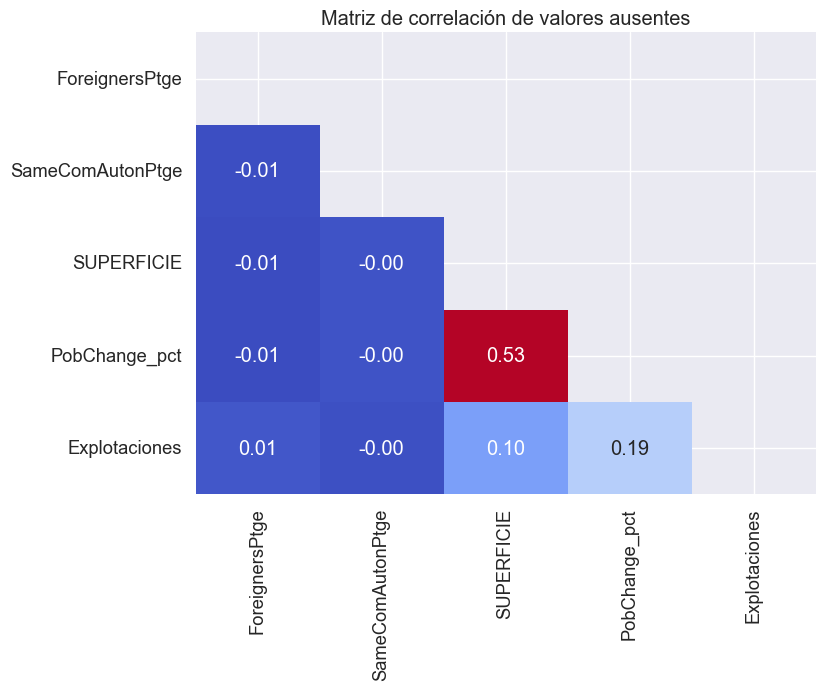

In [12]:
patron_perdidos(df_limpio)

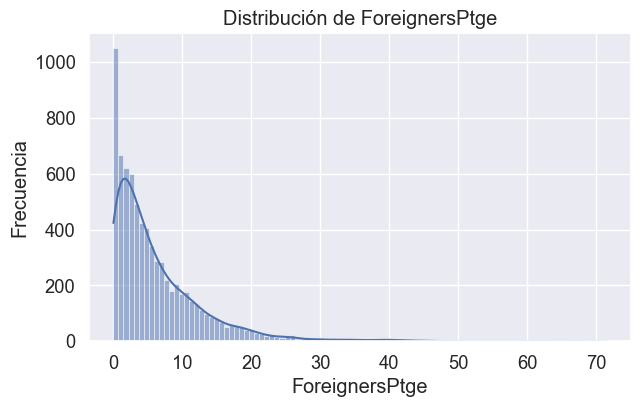

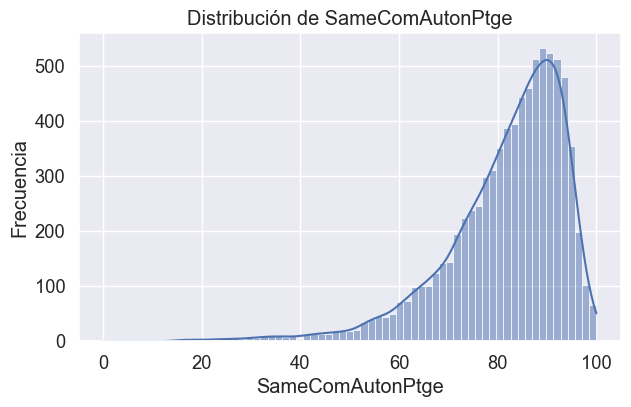

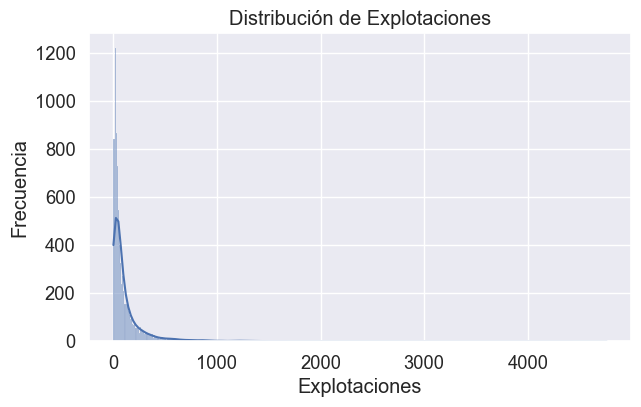

In [13]:
vars_cuant = ['ForeignersPtge', 'SameComAutonPtge', 'Explotaciones']
for var in vars_cuant:
    plt.figure(figsize=(7,4))
    sns.histplot(df_limpio[var], kde=True)
    plt.title(f'Distribución de {var}')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.show()

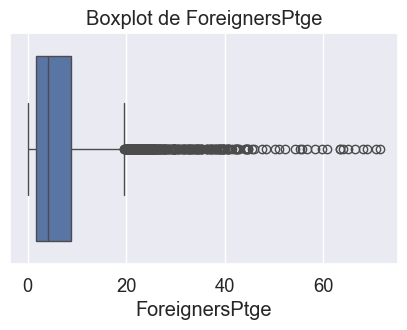

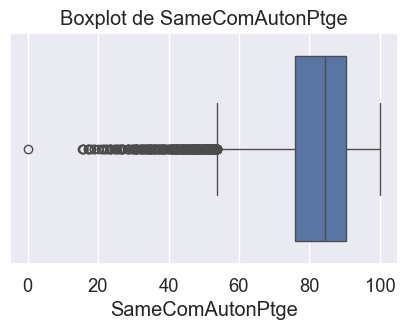

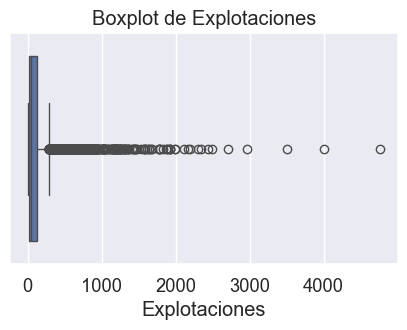

In [14]:
for var in vars_cuant:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df_limpio[var])
    plt.title(f'Boxplot de {var}')
    plt.show()


In [15]:
df_limpio[vars_cuant].describe().T[['mean', '50%', 'std', 'min', 'max']]


,mean,50%,std,min,max
ForeignersPtge,6.342925,4.1300,7.194970,0.0,71.47
SameComAutonPtge,81.622188,84.4925,12.273847,0.0,100.00
Explotaciones,122.229314,50.0000,225.666083,1.0,4759.00



- **Análisis de Outliers**:
    - *La variable "Explotaciones" presenta una distribución fuertemente asimétrica con valores extremos elevados, los cuales se consideran estructurales y representativos de municipios con una elevada actividad. Por tanto, no se eliminan dichos valores y se opta por imputar únicamente los valores perdidos, preservando la información original del conjunto de datos. En tanto y en cuento a lo que refiere en el caso de "ForeignersPtge" y "SameComAutonPtge" se aplica la misma estrtégia, pero se justifican su permanencia, dado que se encuentran dentro del rango factible de valores input.*

In [16]:
# Apply the changes
df_limpio['ForeignersPtge'] = ImputacionCuant(df_limpio['ForeignersPtge'], 'mediana')
df_limpio['SameComAutonPtge'] = ImputacionCuant(df_limpio['SameComAutonPtge'], 'mediana')
df_limpio['Explotaciones'] = ImputacionCuant(df_limpio['Explotaciones'], 'mediana')

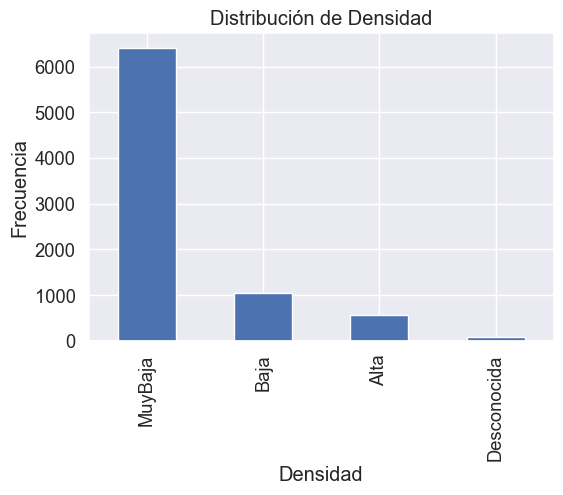

In [17]:
# Categoric var distribution
df_limpio['Densidad'].value_counts(normalize=True)
plt.figure(figsize=(6,4))
df_limpio['Densidad'].value_counts().plot(kind='bar')
plt.title('Distribución de Densidad')
plt.ylabel('Frecuencia')
plt.show()

In [18]:
df_limpio['Densidad'] = ImputacionCuali(df_limpio['Densidad'], 'moda')
df_limpio['Densidad'] = df_limpio['Densidad'].replace({'Desconocida': 'MuyBaja'})

- *Guardamos una **copia del dataframe limpio en formato .pickle**, listo a la espera de ser usado por los modelos que se deseen construir*

In [19]:
# Drop rows with missing values
# Save cleaned data
df_limpio = df_limpio.dropna()
df_limpio.to_pickle("df_limpio.pkl")
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8106 entries, 0 to 8116
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   CCAA                          8106 non-null   category
 1   TotalCensus                   8106 non-null   int64   
 2   AbstentionPtge                8106 non-null   float64 
 3   AbstencionAlta                8106 non-null   bool    
 4   Izda_Pct                      8106 non-null   float64 
 5   Dcha_Pct                      8106 non-null   float64 
 6   Otros_Pct                     8106 non-null   float64 
 7   Izquierda                     8106 non-null   bool    
 8   Derecha                       8106 non-null   bool    
 9   WomanPopulationPtge           8106 non-null   float64 
 10  ForeignersPtge                8106 non-null   float64 
 11  SameComAutonPtge              8106 non-null   float64 
 12  SameComAutonDiffProvPtge      8106 non-null   float64

#### **b) Construcción de los modelos de regresión**

In [20]:
# read cleaned data
df_datos = pd.read_pickle("df_limpio.pkl")

- **Regresión lineal**
  - ***Variable objetivo:** `Dcha_Pct` (porcentaje de votos a partidos de derecha).*
  - ***Justificación de la elección:***
    *`Dcha_Pct` es una variable continua, acotada entre 0 y 100, que permite analizar de forma gradual el efecto de distintas variables socio-demográficas sobre el apoyo electoral a los partidos de derecha. No requiere transformaciones para su modelización y, durante la fase de análisis exploratorio, no se observaron valores elevados de asimetría ni curtosis que sugieran desviaciones importantes respecto a una distribución aproximadamente simétrica.*

    

In [21]:
# Define target
y = df_datos['Dcha_Pct']  # target variable
datos_input = df_datos.drop(columns=['Dcha_Pct', 'Izda_Pct', 'AbstentionPtge', 'Otros_Pct', 'AbstencionAlta', 'Izquierda', 'Derecha'])  # explanatory variables, less targets not selected
datos_input.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8106 entries, 0 to 8116
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   CCAA                          8106 non-null   category
 1   TotalCensus                   8106 non-null   int64   
 2   WomanPopulationPtge           8106 non-null   float64 
 3   ForeignersPtge                8106 non-null   float64 
 4   SameComAutonPtge              8106 non-null   float64 
 5   SameComAutonDiffProvPtge      8106 non-null   float64 
 6   UnemployLess25_Ptge           8106 non-null   float64 
 7   AgricultureUnemploymentPtge   8106 non-null   float64 
 8   IndustryUnemploymentPtge      8106 non-null   float64 
 9   ConstructionUnemploymentPtge  8106 non-null   float64 
 10  ServicesUnemploymentPtge      8106 non-null   float64 
 11  ActividadPpal                 8106 non-null   category
 12  SUPERFICIE                    8106 non-null   float64

In [22]:
# identify categorical and continuous columns
cat_cols = datos_input.select_dtypes(include=["object", "category"]).columns.tolist() #select categorical columns
cont_cols = [c for c in datos_input.columns if c not in cat_cols]


- *Análisis de **correlaciones**:*
    - *Sobre **correlaciones** con la **varible dependiente**:*
    *Se observa que las correlaciones entre las variables explicativas y la variable objetivo son, en general, moderadas o débiles, lo cual es esperable en un fenómeno complejo como el comportamiento electoral, donde la explicación no está dominada por una única variable, sino por el efecto conjunto de múltiples factores. No obstante, algunas variables muestran una mayor relación (en valor absoluto) con el porcentaje de voto a la derecha. En concreto, destacan **"SameComAutonDiffProvPtge" (r ≈ −0.26)**, **"WomanPopulationPtge" (r ≈ −0.22)** y **"PobChange_pct" (r ≈ −0.21)**, indicando que municipios con mayor movilidad territorial, mayor proporción de mujeres o mayor dinamismo poblacional tienden a presentar menores valores de voto a partidos de derechas. Asimismo, variables relacionadas con el desempleo en sectores como la industria y los servicios **("IndustryUnemploymentPtge" y "ServicesUnemploymentPtge")** muestran correlaciones negativas moderadas con la variable objetivo **(en torno a −0.15)**, lo que sugiere un posible efecto socioeconómico sobre el comportamiento electoral.*
    *Por el contrario, otras variables como **"TotalCensus", "SUPERFICIE" o "Explotaciones"** presentan correlaciones prácticamente nulas con la variable objetivo, lo que indica que, de forma aislada, no muestran una relación lineal fuerte con el porcentaje de voto a la derecha. No obstante, estas variables no se descartan en esta fase, ya que podrían adquirir relevancia en presencia de otras variables dentro de un modelo multivariante.*
    - *En cuanto a la **colinealidad** entre **variables explicativas**, la matriz de correlaciones permite identificar algunas relaciones moderadas entre variables de carácter demográfico. En particular, se observa una correlación negativa relativamente elevada entre **"ForeignersPtge y SameComAutonPtge" (r ≈ −0.63)**, lo cual refleja una relación estructural esperable entre la proporción de población extranjera y la población nacida en la misma comunidad autónoma. Si bien esta correlación es relevante, no alcanza niveles de colinealidad severa, por lo que no impide la inclusión conjunta de ambas variables en el modelo inicial.*
    *En conjunto, no se detectan problemas graves de multicolinealidad que invaliden la estimación del modelo de regresión lineal completo. Las relaciones observadas serán tenidas en cuenta en la fase posterior de selección clásica de variables, donde los métodos backward, forward y stepwise basados en criterios de información (AIC y BIC) determinarán de forma objetiva qué variables aportan mayor capacidad explicativa al modelo final.*

In [23]:
# Calculate values of correlations 
matriz_corr = pd.concat([y, datos_input[cont_cols]], axis=1).corr(method='pearson')

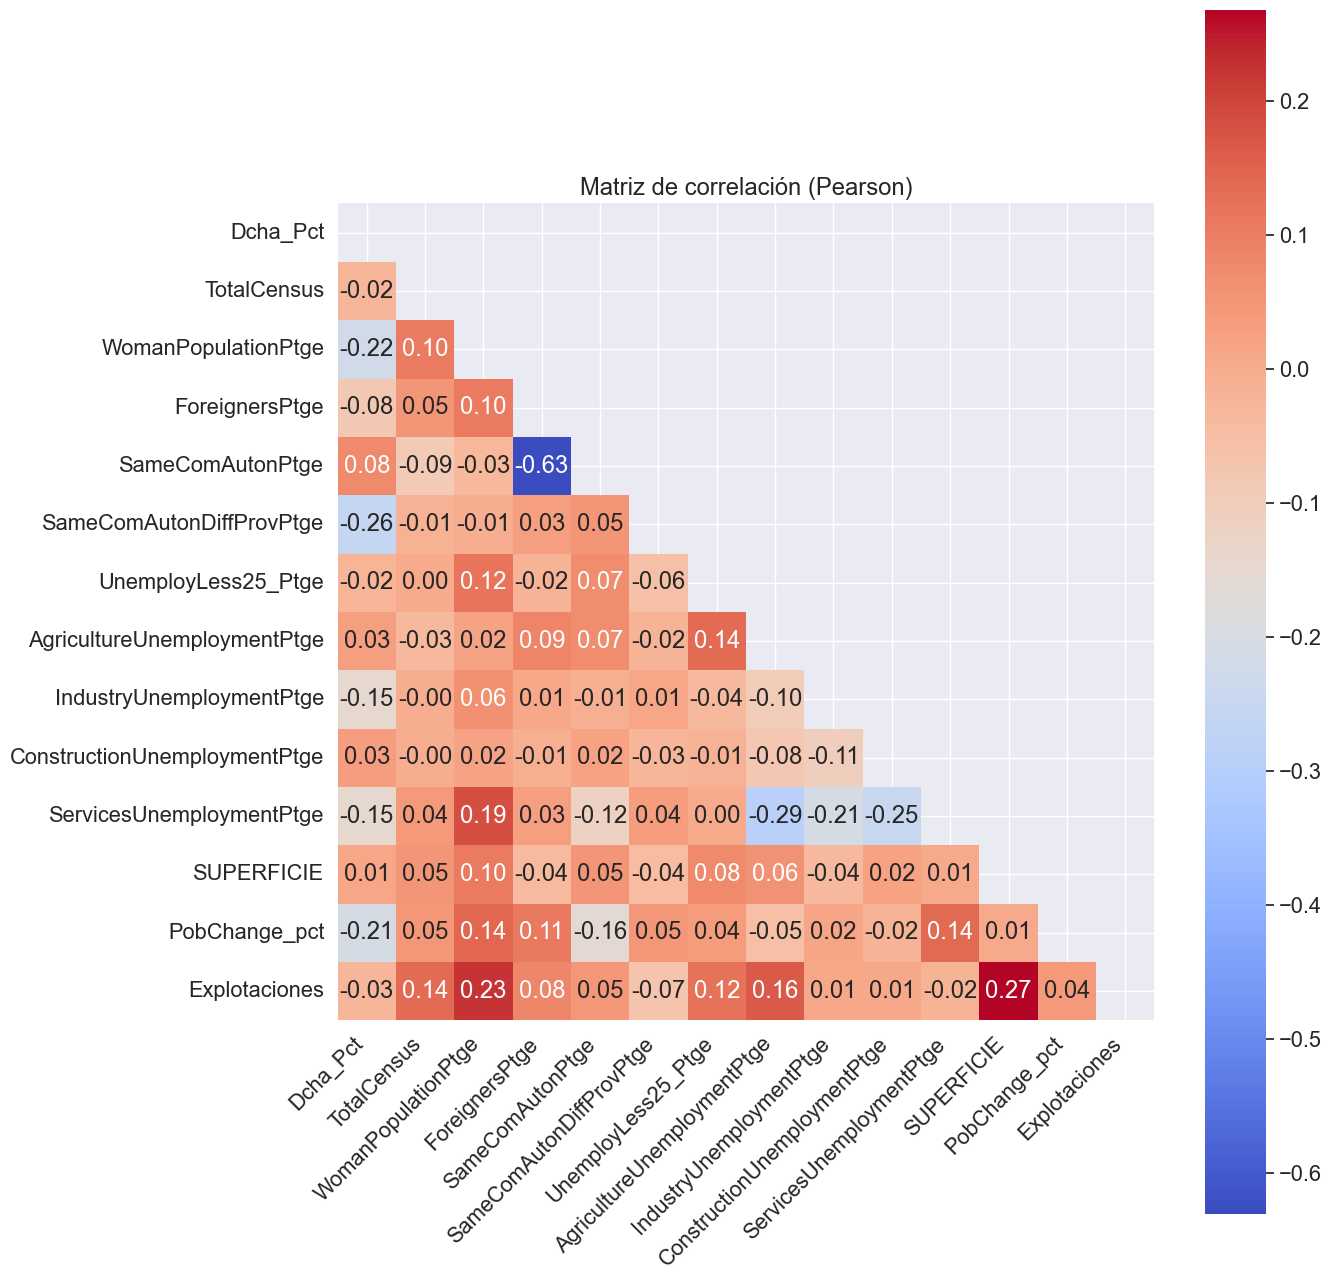

In [24]:
# Create a mask
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

# Calculate dimesions
num_vars = matriz_corr.shape[0]
fig_size = max(10, int(num_vars * 0.7))  
font_scale = max(0.5, min(1.5, 20 / num_vars))  

# Config figure
plt.figure(figsize=(14,14))
sns.set(font_scale=font_scale)

# Create heatmap
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", cbar=True, mask=mask, square=True)

# Emprube Ticks
plt.xticks(rotation=45, ha='right')  # Rotación para evitar solapamiento
plt.yticks(rotation=0)

# Title
plt.title("Matriz de correlación (Pearson)", fontsize=font_scale * 12)
plt.tight_layout()  # Ajuste automático de elementos
plt.show()

- **Contrucción y resultados del modelo de regresión lineal**
    - *Se divide un pirimera isntancia con el método train_test_split los conjuntos de entremineto y testeo.*
    - *Luego se construye el modelo para el conjunto de entrenamiento, sobre los que podemos observar como resultados las siguientes concideraciones:*
        - *El modelo de regresión lineal presenta un **R² = 0.708 y un R² ajustado = 0.707**, lo que indica que aproximadamente el 71 %* de la **variabilidad** del porcentaje de voto a la derecha (Dcha_Pct) es **explicada** por el conjunto de variables explicativas incluidas en el modelo. La cercanía entre R² y R² ajustado sugiere que, pese al elevado número de variables incluidas (35 parámetros), no se observa un sobreajuste extremo en esta fase inicial*
        - *El contraste global del modelo muestra un estadístico **F = 447.0 con un p-valor prácticamente nulo**, lo que permite rechazar la hipótesis nula de que todos los coeficientes sean simultáneamente iguales a cero.*
        - **Coeficientes:**
        *El término constante del modelo toma un valor aproximado de 51,3, lo que indica que el porcentaje medio de voto a la derecha es del **51,3 %** cuando todas las variables explicativas continuas toman valor cero y las variables categóricas se encuentran en su categoría de referencia.*
            - *En **variable categórica "Densidad"**, podemos interpretar que manteniendo constantes el resto de variables explicativas, los municipios con densidad MuyBaja presentan, en promedio, un porcentaje de voto a la derecha aproximadamente **3,2** puntos porcentuales inferior al de los municipios con densidad Alta (categoría de referencia).*
            - *En **varibale continua "ForeignersPtge"**, se sugiere que manteniendo constantes el resto de variables explicativas y permaneciendo en las categorías de referencia de las variables categóricas, un incremento de un punto porcentual en el porcentaje de población extranjera del municipio se asocia, en promedio, con un aumento de 0,175 puntos porcentuales en el porcentaje de voto a partidos de derecha.*
        - **P-valores:** variables como **"ServicesUnemploymentPtge, IndustryUnemploymentPtge y ForeignersPtge"** presentan p-valores muy reducidos **(p < 0.001)**, lo que indica que existe evidencia estadística suficiente para rechazar la hipótesis nula y concluir que estas variables tienen un efecto distinto de cero sobre el porcentaje de voto a la derecha, condicionado al resto de variables del modelo.*
        *Por el contrario, variables como **"TotalCensus", cuyo p-valor es elevado (p ≈ 0.61)**, no permiten rechazar la hipótesis nula, lo que implica que no se dispone de evidencia estadística suficiente para afirmar que su coeficiente sea distinto de cero, una vez controlado el resto de factores incluidos en el modelo. De forma similar, variables con p-valores próximos al umbral de significación, como **"SameComAutonDiffProvPtge" (p ≈ 0.06)**, muestran una evidencia estadística débil o marginal, por lo que su efecto no puede considerarse claramente distinto de cero en este contexto.*

In [25]:
# Split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(datos_input, np.ravel(y), test_size = 0.2, random_state = 123456)

In [26]:
# Build full linear model with all variables
modelo_full = lm(y_train, x_train, cont_cols, cat_cols)
print(modelo_full['Modelo'].summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.707
Method:                 Least Squares   F-statistic:                     447.0
Date:                Fri, 16 Jan 2026   Prob (F-statistic):               0.00
Time:                        18:58:08   Log-Likelihood:                -24664.
No. Observations:                6484   AIC:                         4.940e+04
Df Residuals:                    6448   BIC:                         4.964e+04
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

- **Contraste del modelo contra test: Análisis de sesgo y varianza**
    - *El modelo presenta valores de R² similares en las muestras de entrenamiento y test, con una ligera disminución en esta última. Esta diferencia moderada sugiere que el modelo no incurre en sobreajuste significativo y mantiene una capacidad de generalización adecuada.*

In [27]:
# Compute R^2 on the training data
Rsq(modelo_full['Modelo'], y_train, modelo_full['X'])

np.float64(0.7081314590177847)

In [28]:
# Prepare test data to be used in the model
x_test_modelo_full = crear_data_modelo(x_test, cont_cols, cat_cols)
# Compute R^2 on the test data
Rsq(modelo_full['Modelo'], y_test, x_test_modelo_full)

np.float64(0.6753995444670005)

- **Selección clásica**: *El modelo de regresión lineal completo presenta una elevada capacidad explicativa y resultados coherentes desde el punto de vista socioeconómico y demográfico. No obstante, la presencia de variables no significativas y la posible redundancia entre algunas de ellas justifican la aplicación de métodos de selección clásica con el objetivo de obtener un modelo más parsimonioso.*
    - **Backward(AIC):** *En las primeras iteraciones, las variables **"TotalCensus y SUPERFICIE"" son eliminadas**, ya que su exclusión reduce el AIC del modelo. Este resultado sugiere que dichas variables no aportan capacidad explicativa adicionl una vez incluidas otras variables*
    - **Backward(BIC):** *conduce a un modelo considerablemente más parsimonioso que el obtenido mediante AIC. Tras eliminar variables estructurales como **"TotalCensus y SUPERFICIE""**, el criterio BIC continúa descartando variables demográficas y económicas cuyo aporte marginal no compensa la penalización por complejidad, como **"SameComAutonDiffProvPtge, Explotaciones o ActividadPpal"**.*

In [29]:
Modelo_Back_Aic = lm_backward(y_train, x_train, cont_cols, cat_cols, var_interac = [], metodo = 'AIC')

Start: AIC = 49399.40080833226

y ~ TotalCensus + WomanPopulationPtge + ForeignersPtge + SameComAutonPtge + SameComAutonDiffProvPtge + UnemployLess25_Ptge + AgricultureUnemploymentPtge + IndustryUnemploymentPtge + ConstructionUnemploymentPtge + ServicesUnemploymentPtge + SUPERFICIE + PobChange_pct + Explotaciones + CCAA + ActividadPpal + Densidad

                       Variable          AIC
                         - CCAA 55866.178648
     - ServicesUnemploymentPtge 49493.728409
               - ForeignersPtge 49439.576919
     - IndustryUnemploymentPtge 49433.206593
                - ActividadPpal 49423.092522
                     - Densidad 49417.686095
                - PobChange_pct 49411.969660
          - WomanPopulationPtge 49410.797438
 - ConstructionUnemploymentPtge 49410.748025
          - UnemployLess25_Ptge 49408.987069
             - SameComAutonPtge 49403.168629
  - AgricultureUnemploymentPtge 49401.723044
                - Explotaciones 49401.666403
     - SameComAutonD

In [30]:
Modelo_Back_Bic = lm_backward(y_train, x_train, cont_cols, cat_cols, var_interac = [], metodo = 'BIC')

Start: BIC = 49643.376152115066

y ~ TotalCensus + WomanPopulationPtge + ForeignersPtge + SameComAutonPtge + SameComAutonDiffProvPtge + UnemployLess25_Ptge + AgricultureUnemploymentPtge + IndustryUnemploymentPtge + ConstructionUnemploymentPtge + ServicesUnemploymentPtge + SUPERFICIE + PobChange_pct + Explotaciones + CCAA + ActividadPpal + Densidad

                       Variable          BIC
                         - CCAA 56001.720505
     - ServicesUnemploymentPtge 49730.926660
               - ForeignersPtge 49676.775170
     - IndustryUnemploymentPtge 49670.404844
                - PobChange_pct 49649.167910
                     - Densidad 49648.107253
          - WomanPopulationPtge 49647.995689
 - ConstructionUnemploymentPtge 49647.946276
          - UnemployLess25_Ptge 49646.185320
             - SameComAutonPtge 49640.366880
                - ActividadPpal 49639.959494
  - AgricultureUnemploymentPtge 49638.921295
                - Explotaciones 49638.864654
     - SameComAuton

- **Elección del modelo ganador:** 
    - *El modelo Backward BIC presenta un R² en entrenamiento de 0,706 y un R² en test de 0,670, valores ligeramente inferiores a los de los otros modelos. No obstante, esta reducción en capacidad explicativa es muy moderada, mientras que la disminución en el número de parámetros es sustancial, pasando de 36 a 26. Esto implica una reducción significativa de la complejidad del modelo, lo que mejora su parsimonia, estabilidad e interpretabilidad.*
    Conclusión (modelo ganador)
    - *En base a estos resultados, **se selecciona el modelo Backward BIC como modelo ganador**, ya que logra un adecuado equilibrio entre capacidad predictiva y complejidad, manteniendo un rendimiento fuera de muestra similar al de los modelos más complejos, pero con un número significativamente menor de parámetros.*

In [31]:
def evaluar_modelo_lm(nombre_modelo, metrica, modelo_dict, x_test, y_test, y_train):
    # R^2 Train (X ya preparado en el modelo)
    r2_train = Rsq(modelo_dict['Modelo'], y_train, modelo_dict['X'])

    # Variables usadas por el modelo
    var_cont = modelo_dict['Variables']['cont']
    var_categ = modelo_dict['Variables']['categ']
    var_inter = modelo_dict['Variables'].get('inter', [])

    # Prepare X_test with the same variables/dummies structure
    x_test_preparado = crear_data_modelo(x_test, var_cont, var_categ, var_inter)

    # R^2 Test
    r2_test = Rsq(modelo_dict['Modelo'], y_test, x_test_preparado)

    # Nº de parámetros (incluye constante)
    n_param = int(modelo_dict['Modelo'].df_model + 1)

    return {
        "Método": nombre_modelo,
        "Métrica": metrica,
        "R^2 Train": float(r2_train),
        "R^2 Test": float(r2_test),
        "Nº Parámetros": n_param
    }

# Build the table with your 3 models
resultados = []
resultados.append(evaluar_modelo_lm("Full", "-", modelo_full, x_test, y_test, y_train))
resultados.append(evaluar_modelo_lm("Backward", "AIC", Modelo_Back_Aic, x_test, y_test, y_train))
resultados.append(evaluar_modelo_lm("Backward", "BIC", Modelo_Back_Bic, x_test, y_test, y_train))

tabla_resultados = pd.DataFrame(resultados)
tabla_resultados


,Método,Métrica,R^2 Train,R^2 Test,Nº Parámetros
0,Full,-,0.708131,0.675400,36
1,Backward,AIC,0.708058,0.675446,34
2,Backward,BIC,0.705886,0.670286,26


In [32]:
print(Modelo_Back_Bic['Modelo'].summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.706
Model:                            OLS   Adj. R-squared:                  0.705
Method:                 Least Squares   F-statistic:                     620.0
Date:                Fri, 16 Jan 2026   Prob (F-statistic):               0.00
Time:                        18:58:16   Log-Likelihood:                -24689.
No. Observations:                6484   AIC:                         4.943e+04
Df Residuals:                    6458   BIC:                         4.961e+04
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

- **Regresión Logística**
  - ***Variable objetivo:** `AbstencionAlta` (porcentaje de votos a partidos de derecha).*
  - ***Justificación de la elección:***
    *`AbstencionAlta` es una variable buleana que puede tomar exclusivamente 2 valores: 0 o 1. Que permite analizar de forma gradual el efecto de distintas variables socio-demográficas en relación a la asbtención al voto en una elección. No requiere transformaciones para su modelización (tiene 2 valores únicos) y, durante la fase de análisis exploratorio, se observo una representación o proporción de sus valores equilibrada dentro del conjunto de datos orginal.

In [33]:
# Define target
y2 = df_datos['AbstencionAlta']  # target variable

- *Análisis de **Vcrumer**:*
    - *Sobre **Vcramer** con la **varible categóricas**:*
        - *Las variables categóricas muestran distintos niveles de asociación con la variable objetivo AbstencionAlta. En particular, CCAA presenta una asociación fuerte, lo que indica que la probabilidad de abstención alta varía significativamente entre comunidades autónomas. ActividadPpal y Densidad muestran asociaciones de magnitud moderada, sugiriendo que el tipo de actividad económica dominante y el nivel de densidad poblacional también están relacionados con el nivel de abstención, aunque en menor medida.*
    - *El análisis de la V de Cramer muestra que tanto factores territoriales como socioeconómicos presentan asociaciones relevantes con la abstención alta, justificando la inclusión de estas variables en el modelo de regresión logística, donde se evaluará su efecto conjunto y condicionado.*

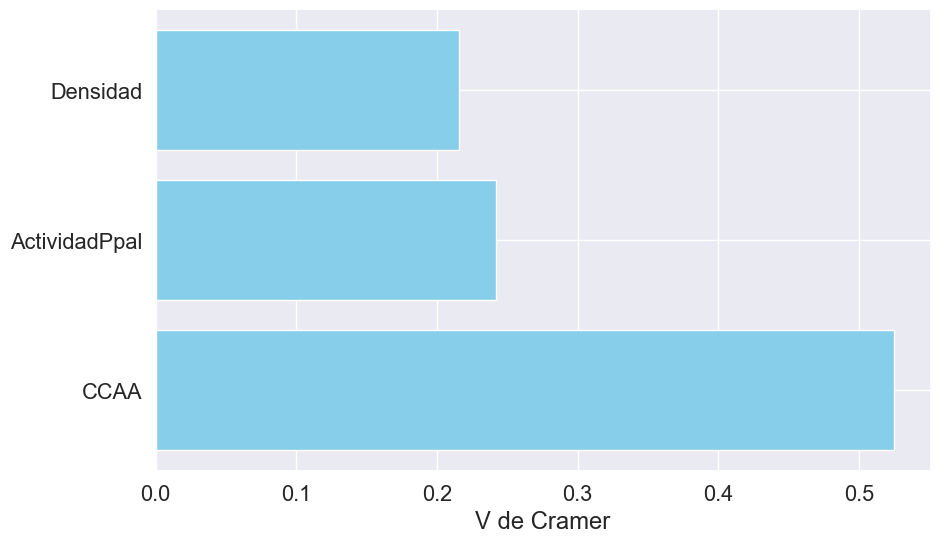

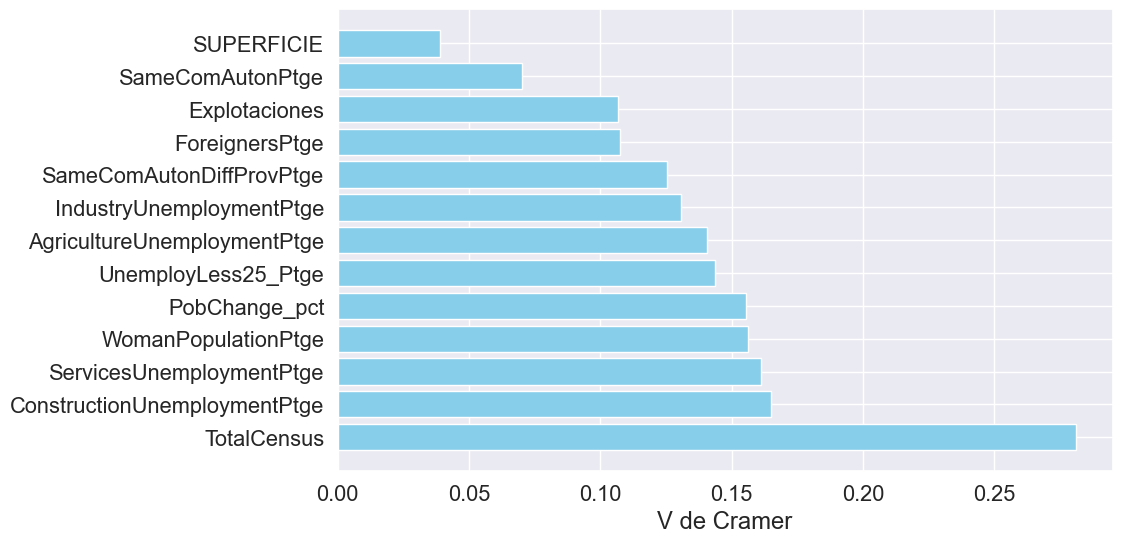

In [34]:
graficoVcramer(datos_input[cat_cols],y2)
graficoVcramer(datos_input[cont_cols],y2)

In [35]:
# Split data into training and testing sets
x_train2, x_test2, y_train2, y_test2 = train_test_split(datos_input, np.ravel(y2), test_size = 0.2, random_state = 123456)
# Change type to int for "y2" values
y_train2, y_test2 = y_train2.astype(int), y_test2.astype(int)

- **Contrucción y resultados del modelo de regresión logística**
    - *Se divide un pirimera isntancia con el método train_test_split los conjuntos de entremineto y testeo.*
    - *Luego se construye el modelo para el conjunto de entrenamiento, sobre los que podemos observar como resultados las siguientes concideraciones:*
        - **Coeficientes:**
        *En el grupo de referencia definido por el modelo, las odds de abstención alta son elevadas (aprox = 2,57), lo que indica que, incluso antes de considerar el efecto del resto de variables, existe una propensión base importante a la abstención alta.*
            - *En **varibale continua "SameComAutonPtge"**: Por cada aumento de un punto porcentual en **"SameComAutonPtge"**, las odds de presentar una abstención alta se **reducen aproximadamente en un 1,8 %**, manteniendo constantes el resto de variables.*
            - *En **variable categórica "Densidad"**: Los municipios con densidad baja presentan unas **odds ratio**(OR=e**−0.506≈0.60) de abstención alta aproximadamente un **60 %** menores que los municipios con densidad alta, manteniendo constantes el resto de variables.*
        - **P-valores:** *En el modelo logístico estimado se observa que varias variables presentan efectos estadísticamente significativos sobre la probabilidad de abstención alta una vez controlado el resto de factores. Por ejemplo, **"SameComAutonPtge" muestra un coeficiente de −0,0186 con un p-valor < 0,001**. Asimismo, el factor territorial resulta especialmente relevante: numerosas categorías de CCAA presentan coeficientes altamente significativos, como **Cataluña (coef. = 2,16; p < 0,001)** o **Comunidad Valenciana (coef. = −2,92; p < 0,001)**, lo que confirma que la probabilidad de abstención alta varía de forma sustancial entre comunidades*
        Por el contrario, otras variables como **"TotalCensus" (coef. ≈ 0; p = 0,79)**, **"IndustryUnemploymentPtge (p = 0,63)"** o **"ServicesUnemploymentPtge" (p = 0,50)** no presentan evidencia estadística suficiente para afirmar que su efecto sea distinto de cero en presencia del resto de variables del modelo, lo que sugiere que su información queda absorbida por otros factores incluidos en la especificación.

In [36]:
# Build full linear model with all variables
modelo_inicial = glm(y_train2, x_train2, cont_cols, cat_cols)

In [37]:
X_train_glm = modelo_inicial['X'].astype(float)
summary_glm(modelo_inicial['Modelo'], y_train2, X_train_glm)

{'Contrastes':                         Variable      Estimate  Std. Error    z value  \
 0                    (Intercept)  2.569410e+00    0.581537   4.418305   
 1                    TotalCensus -4.322407e-07    0.000002  -0.260456   
 2            WomanPopulationPtge -1.590799e-02    0.009231  -1.723311   
 3                 ForeignersPtge  9.995638e-03    0.006547   1.526836   
 4               SameComAutonPtge -1.856390e-02    0.003789  -4.899614   
 5       SameComAutonDiffProvPtge -1.198531e-02    0.005868  -2.042314   
 6            UnemployLess25_Ptge -3.150880e-03    0.004000  -0.787673   
 7    AgricultureUnemploymentPtge -9.640546e-03    0.003406  -2.830862   
 8       IndustryUnemploymentPtge -1.454677e-03    0.003059  -0.475616   
 9   ConstructionUnemploymentPtge  8.441662e-03    0.002613   3.231098   
 10      ServicesUnemploymentPtge  1.179887e-03    0.001742   0.677199   
 11                    SUPERFICIE  1.077109e-05    0.000003   3.165213   
 12                 PobC

- *Interpretación del **pseudo R2** en entrenamiento y test*
    - *El modelo de regresión logística presenta un pseudo **R2 de 0,255** en la muestra de **entrenamiento**. Este valor sugiere que el modelo captura una parte relevante de la información asociada a la probabilidad de abstención alta, aunque, como es habitual en modelos logísticos, el pseudo R2 no alcanza niveles comparables al R2 de una regresión lineal.*
    - *En la muestra de **test**, el pseudo R2 obtenido es **0,261**, valor muy similar al observado en entrenamiento e incluso ligeramente superior. Esta estabilidad entre train y test indica que el modelo mantiene su capacidad explicativa fuera de la muestra utilizada para el ajuste, sin evidencias de sobreajuste. La consistencia de los valores del pseudo R2 sugiere que las relaciones estimadas entre las variables explicativas y la abstención alta son robustas y generalizables.*

In [38]:
# Calculamos la medida de ajuste R^2 para los datos de entrenamiento
pseudoR2(modelo_inicial['Modelo'], X_train_glm, y_train2)

Optimization terminated successfully.
         Current function value: 0.619342
         Iterations 5


np.float64(0.25501312145384003)

In [39]:
# Preparamos los datos test para usar en el modelo
x_test_modeloInicial = crear_data_modelo(x_test2, cont_cols, cat_cols)

In [40]:
# Calculamos la medida de ajuste R^2 para los datos test
pseudoR2(modelo_inicial['Modelo'], x_test_modeloInicial, y_test2)

Optimization terminated successfully.
         Current function value: 0.620660
         Iterations 5


np.float64(0.2607140132788329)

In [41]:
# Calculamos el número de parámetros utilizados en el modelo.
len(modelo_inicial['Modelo'].coef_[0])

35

Optimization terminated successfully.
         Current function value: 0.619342
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.619342
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.619342
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.619342
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.619342
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.619342
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.619342
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.619342
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.619342
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.619342
  

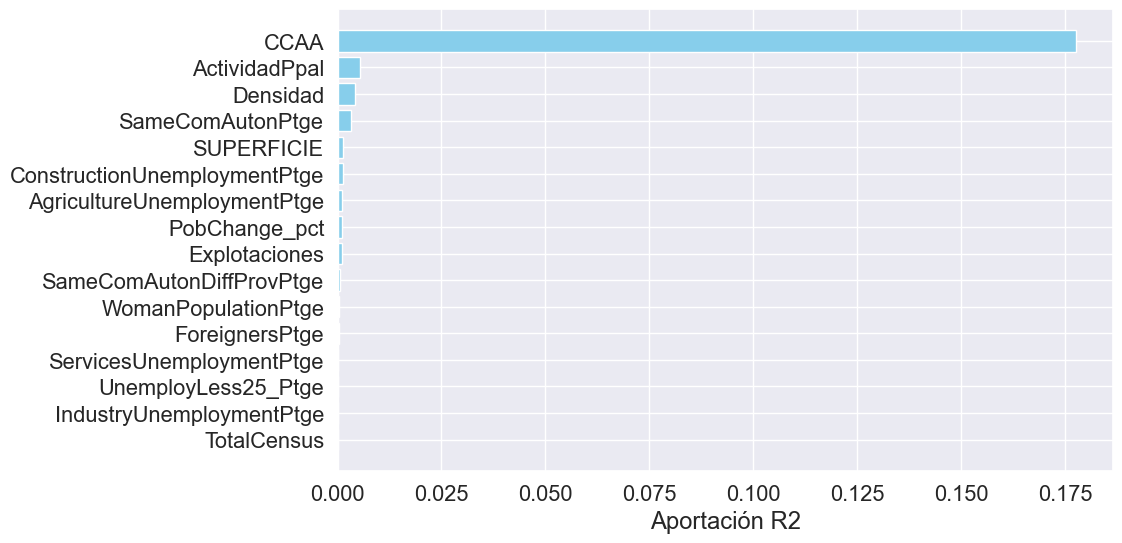

,Variables,R2
0,TotalCensus,0.000015
7,IndustryUnemploymentPtge,0.000022
5,UnemployLess25_Ptge,0.000098
9,ServicesUnemploymentPtge,0.000102
2,ForeignersPtge,0.000310
1,WomanPopulationPtge,0.000428
4,SameComAutonDiffProvPtge,0.000645
12,Explotaciones,0.000960
11,PobChange_pct,0.001043
6,AgricultureUnemploymentPtge,0.001058


In [42]:
# Importancia de las variables
impVariablesLog(modelo_inicial, y_train2, x_train2, cont_cols, cat_cols)

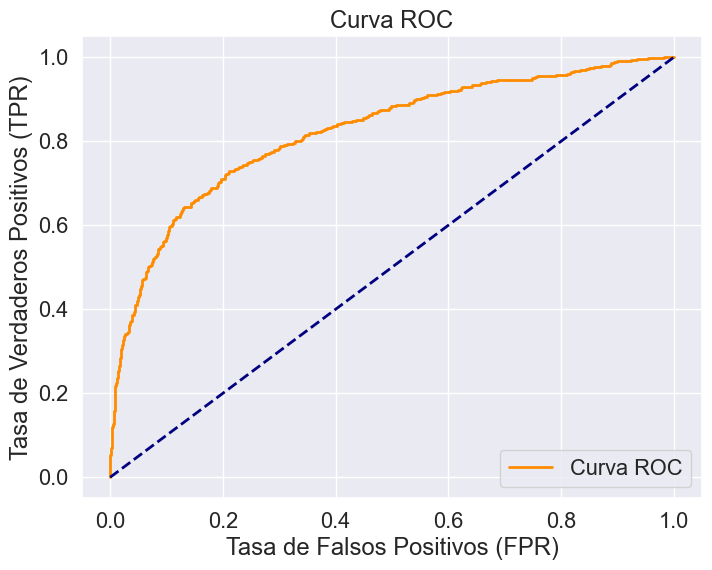

Área bajo la curva ROC = 0.8228374204881919


In [43]:
# Calculamos el area bajo la curva ROC y representamos
AUC1 = curva_roc(x_test_modeloInicial, y_test2, modelo_inicial)

- **Elección del modelo ganador:** 
- *A partir de la comparación entre el modelo completo y los modelos seleccionados mediante stepwise, se observa que el modelo stepwise (AIC/BIC) presenta una capacidad explicativa prácticamente idéntica a la del modelo completo, tanto en la muestra de entrenamiento como en la de test. En concreto, el **pseudo R2** en test del modelo completo es **0,261**, mientras que el del **modelo stepwise** es **0,260**, lo que indica que la reducción del modelo no implica una pérdida relevante de capacidad predictiva fuera de la muestra.*
- *Al mismo tiempo, el modelo stepwise reduce de forma significativa la complejidad del modelo, **pasando de 36 a 29 parámetros**, lo que supone una eliminación de variables cuyo aporte marginal era reducido o redundante. Esta ganancia en parsimonia se refleja claramente en los criterios de información: el modelo stepwise presenta un AIC inferior al del modelo completo (6050,35 frente a 6051,93) y, especialmente, una reducción muy marcada del BIC (6246,89 frente a 6295,91).*

In [44]:
# Stepwise logistic models
modeloRL_step_AIC = glm_stepwise(y_train2, x_train2, cont_cols, cat_cols, var_interac=[], metodo='AIC')
modeloRL_step_BIC = glm_stepwise(y_train2, x_train2, cont_cols, cat_cols, var_interac=[], metodo='BIC')

Start: AIC = 8035.632152566761

y ~ 1

                       Variable         AIC
                         + CCAA 6258.347928
                + ActividadPpal 7686.948036
                     + Densidad 7754.662384
          + WomanPopulationPtge 7915.776144
     + SameComAutonDiffProvPtge 7937.826654
                + PobChange_pct 7973.971097
               + ForeignersPtge 7975.326841
                  + TotalCensus 7981.843425
             + SameComAutonPtge 7993.844700
                + Explotaciones 7999.914701
  + AgricultureUnemploymentPtge 8009.295385
     + ServicesUnemploymentPtge 8012.641018
     + IndustryUnemploymentPtge 8015.026085
 + ConstructionUnemploymentPtge 8027.329712
                   + SUPERFICIE 8031.473369
          + UnemployLess25_Ptge 8031.614922

--------------------------------------- Step Forward: Entra CCAA

AIC = 6258.347928414413

y ~ CCAA

                       Variable         AIC
                + ActividadPpal 6145.350245
                     + 

In [45]:
def aic_bic_statsmodels(X, y):
    X = X.astype(float)
    y = y.astype(int)
    X_design = sm.add_constant(X, has_constant='add')
    res = sm.Logit(y, X_design).fit(disp=0)
    return float(res.aic), float(res.bic)

aic_full, bic_full = aic_bic_statsmodels(modelo_inicial['X'], y_train2)
aic_aic,  bic_aic  = aic_bic_statsmodels(modeloRL_step_AIC['X'], y_train2)
aic_bic,  bic_bic  = aic_bic_statsmodels(modeloRL_step_BIC['X'], y_train2)

In [46]:
def evaluar_glm(nombre, metrica, modelo_dict, x_test, y_train, y_test):
    # X train ya preparado dentro del modelo (mismas dummies)
    X_train = modelo_dict['X'].astype(float)

    # Preparar X_test con las variables del modelo
    var_cont = modelo_dict['Variables']['cont']
    var_categ = modelo_dict['Variables']['categ']
    var_inter = modelo_dict['Variables'].get('inter', [])
    X_test_modelo = crear_data_modelo(x_test, var_cont, var_categ, var_inter).astype(float)

    # pseudoR2 train/test (función del profe)
    pr2_train = float(pseudoR2(modelo_dict['Modelo'], X_train, y_train))
    pr2_test  = float(pseudoR2(modelo_dict['Modelo'], X_test_modelo, y_test))

    # AIC/BIC con statsmodels (sobre train)
    aic, bic = aic_bic_statsmodels(X_train, y_train)

    # Nº parámetros (coeficientes + intercepto)
    n_param = int(modelo_dict['Modelo'].coef_.shape[1] + 1)

    return {
        "Método": nombre,
        "Métrica": metrica,
        "pseudoR2 Train": pr2_train,
        "pseudoR2 Test": pr2_test,
        "AIC": aic,
        "BIC": bic,
        "Nº Parámetros": n_param
    }

tabla_glm = pd.DataFrame([
    evaluar_glm("Full", "-", modelo_inicial, x_test2, y_train2, y_test2),
    evaluar_glm("Stepwise", "AIC", modeloRL_step_AIC, x_test2, y_train2, y_test2),
    evaluar_glm("Stepwise", "BIC", modeloRL_step_BIC, x_test2, y_train2, y_test2)
])

Optimization terminated successfully.
         Current function value: 0.619342
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.620660
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.619342
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.620660
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.619342
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.620660
         Iterations 5


In [47]:
tabla_glm.loc[0, ["AIC","BIC"]] = [aic_full, bic_full]
tabla_glm.loc[1, ["AIC","BIC"]] = [aic_aic, bic_aic]
tabla_glm.loc[2, ["AIC","BIC"]] = [aic_bic, bic_bic]

tabla_glm
 

,Método,Métrica,pseudoR2 Train,pseudoR2 Test,AIC,BIC,Nº Parámetros
0,Full,-,0.255013,0.260714,6051.930853,6295.906197,36
1,Stepwise,AIC,0.253486,0.259714,6050.353468,6246.889162,29
2,Stepwise,BIC,0.253486,0.259714,6050.353468,6246.889162,29


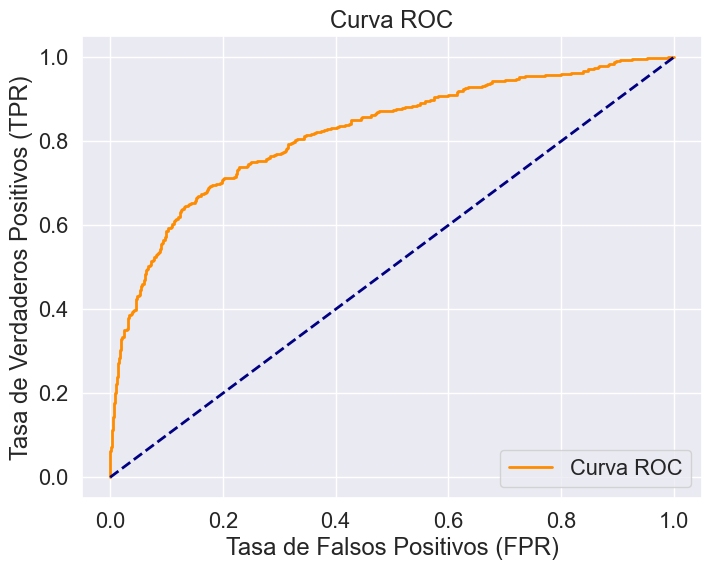

Área bajo la curva ROC = 0.8210577018431157


In [48]:
x_test_step_AIC = crear_data_modelo(
    x_test2,
    modeloRL_step_AIC['Variables']['cont'],
    modeloRL_step_AIC['Variables']['categ'],
    modeloRL_step_AIC['Variables'].get('inter', [])
)

AUC_step_AIC = curva_roc(x_test_step_AIC, y_test2, modeloRL_step_AIC)


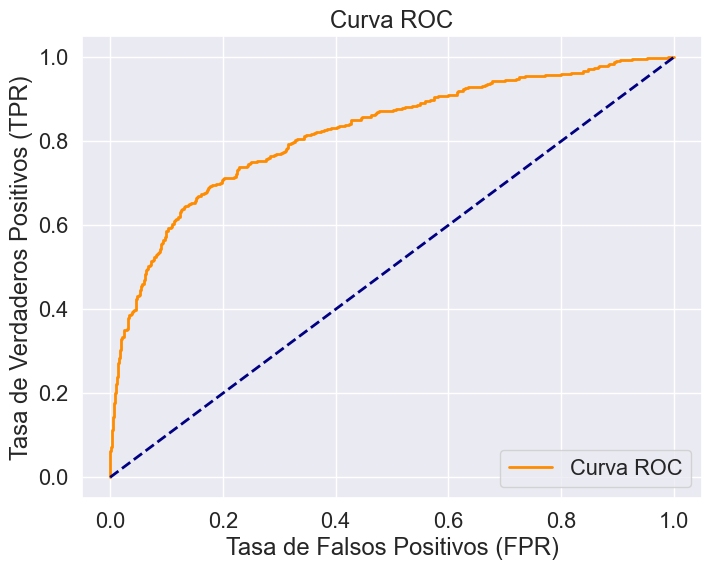

Área bajo la curva ROC = 0.8210577018431157


In [49]:
x_test_step_BIC = crear_data_modelo(
    x_test2,
    modeloRL_step_BIC['Variables']['cont'],
    modeloRL_step_BIC['Variables']['categ'],
    modeloRL_step_BIC['Variables'].get('inter', [])
)

AUC_step_BIC = curva_roc(x_test_step_BIC, y_test2, modeloRL_step_BIC)


- **Interpretación del punto de corte óptimo según Youden (0.32)**
    - Resultados:
        - Punto de corte: 0.32
        - Accuracy: 0.78
        - Sensitivity: 0.69
        - Specificity: 0.82
        - PV: 0.63
        - NPV: 0.86

    - Con un **punto de corte de 0.32**, el modelo logra un equilibrio razonable entre sensibilidad y especificidad, priorizando la capacidad de detectar correctamente los municipios con abstención alta. En concreto, el modelo identifica correctamente aproximadamente el 69% de los casos de abstención alta, al mismo tiempo que clasifica correctamente cerca del 82% de los municipios sin abstención alta.
    - **Este punto de corte reduce el riesgo de falsos negativos**, es decir, casos de abstención alta que el modelo clasificaría erróneamente como baja. Dado que el objetivo del análisis es explicar y detectar patrones asociados a una abstención elevada, este comportamiento resulta especialmente relevante, ya que permite capturar una mayor proporción de los municipios problemáticos desde el punto de vista de la participación electoral.
    - El valor elevado del **Negative Predictive Value (0.86)** indica además que, cuando el modelo predice que no hay abstención alta, dicha predicción es altamente fiable.

- **Interpretación del punto de corte óptimo según Accuracy (0.42)**

    - Resultados:
        - Punto de corte: 0.42
        - Accuracy: 0.80
        - Sensitivity: 0.59
        - Specificity: 0.90
        - PPV: 0.72
        - NPV: 0.83

    - Con un **punto de corte de 0.42**, el modelo maximiza el porcentaje global de aciertos, alcanzando una accuracy del 80%. Sin embargo, esta mejora en el acierto total se logra a costa de una reducción notable de la sensibilidad, ya que el modelo solo identifica correctamente alrededor del 59% de los municipios con abstención alta.
    - **Este punto de corte favorece claramente la especificidad (≈ 90%)**, lo que implica que el modelo es muy conservador a la hora de clasificar municipios como de abstención alta. En consecuencia, disminuye los falsos positivos, pero incrementa los falsos negativos, dejando sin detectar una proporción relevante de municipios con problemas reales de abstención.
    - **Este comportamiento puede ser adecuado en contextos donde el coste de clasificar erróneamente un municipio como de abstención alta sea elevado, pero no es el escenario principal de este estudio.**

#### **Decisión final**
- Dado que el objetivo del análisis es explicar y detectar municipios con abstención alta, resulta más adecuado priorizar la capacidad de detección frente al acierto global. En este contexto, el coste de no identificar un municipio con abstención elevada es mayor que el de clasificar erróneamente algún municipio como de riesgo.
**Se selecciona para el modelo "modeloRL_step_BIC", un punto de corte óptimo de 0.32**, obtenido a partir del índice de Youden, ya que proporciona un mejor equilibrio entre sensibilidad y especificidad y permite identificar una mayor proporción de municipios con abstención alta.

In [50]:
var_cont_BIC = modeloRL_step_BIC['Variables']['cont']
var_categ_BIC = modeloRL_step_BIC['Variables']['categ']


In [51]:
sensEspCorte(modeloRL_step_BIC['Modelo'], x_test2, y_test2, 0.4, var_cont_BIC, var_categ_BIC)
sensEspCorte(modeloRL_step_BIC['Modelo'], x_test2, y_test2, 0.6, var_cont_BIC, var_categ_BIC)


,PtoCorte,Accuracy,Sensitivity,Specificity,PosPredValue,NegPredValue
0,0.6,0.787916,0.432806,0.948925,0.793478,0.786776


In [52]:
posiblesCortes = np.arange(0, 1.01, 0.01).tolist()

rejilla = pd.DataFrame({
    'PtoCorte': [],
    'Accuracy': [],
    'Sensitivity': [],
    'Specificity': [],
    'PosPredValue': [],
    'NegPredValue': []
})

for pto_corte in posiblesCortes:
    rejilla = pd.concat(
        [rejilla, sensEspCorte(modeloRL_step_BIC['Modelo'], x_test2, y_test2, pto_corte, var_cont_BIC, var_categ_BIC)],
        axis=0
    )

rejilla['Youden'] = rejilla['Sensitivity'] + rejilla['Specificity'] - 1
rejilla.index = list(range(len(rejilla)))


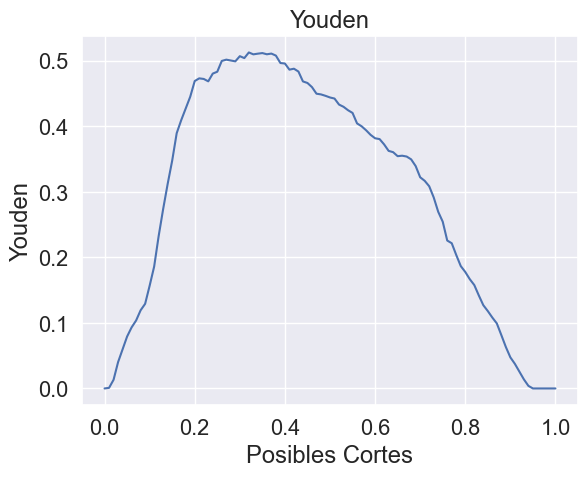

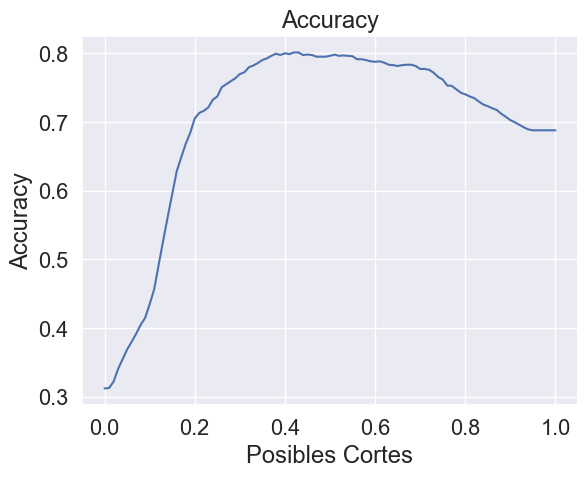

In [53]:
plt.plot(rejilla['PtoCorte'], rejilla['Youden'])
plt.xlabel('Posibles Cortes')
plt.ylabel('Youden')
plt.title('Youden')
plt.show()

plt.plot(rejilla['PtoCorte'], rejilla['Accuracy'])
plt.xlabel('Posibles Cortes')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.show()


In [54]:
corte_youden = rejilla['PtoCorte'][rejilla['Youden'].idxmax()]
corte_accuracy = rejilla['PtoCorte'][rejilla['Accuracy'].idxmax()]

corte_youden, corte_accuracy


(np.float64(0.32), np.float64(0.42))

In [55]:
sensEspCorte(modeloRL_step_BIC['Modelo'], x_test2, y_test2, corte_youden, var_cont_BIC, var_categ_BIC)



,PtoCorte,Accuracy,Sensitivity,Specificity,PosPredValue,NegPredValue
0,0.32,0.779901,0.693676,0.818996,0.63472,0.855005


In [56]:
sensEspCorte(modeloRL_step_BIC['Modelo'], x_test2, y_test2, corte_accuracy, var_cont_BIC, var_categ_BIC)

,PtoCorte,Accuracy,Sensitivity,Specificity,PosPredValue,NegPredValue
0,0.42,0.80148,0.590909,0.896953,0.722222,0.828642


In [60]:
X_train_glm_bic = modeloRL_step_BIC['X'].astype(float)
summary_glm(modeloRL_step_BIC['Modelo'], y_train2, X_train_glm_bic)

{'Contrastes':                         Variable  Estimate  Std. Error    z value   p value  \
 0                    (Intercept)  2.124047    0.299674   7.087861  0.000000   
 1               SameComAutonPtge -0.022555    0.003045  -7.406377  0.000000   
 2                     SUPERFICIE  0.000010    0.000003   3.026195  0.002486   
 3   ConstructionUnemploymentPtge  0.008237    0.002386   3.452855  0.000558   
 4                  PobChange_pct -0.011054    0.003749  -2.948755  0.003202   
 5    AgricultureUnemploymentPtge -0.009601    0.003129  -3.068816  0.002158   
 6                  Explotaciones  0.000434    0.000158   2.746532  0.006040   
 7                    CCAA_Aragón -0.497763    0.147664  -3.370906  0.000754   
 8                  CCAA_Asturias  1.699178    0.336870   5.044023  0.000000   
 9                  CCAA_Baleares  0.979237    0.335066   2.922516  0.003484   
 10                 CCAA_Canarias  1.036842    0.297816   3.481482  0.000502   
 11                CCAA_Ca